# 4. 평가 및 시각화

RandomForest, LightGBM, XGBoost, AutoGluon Best Model, Ensemble 5개 모델을 비교합니다.

In [4]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_curve, auc
)
import lightgbm as lgb
import xgboost as xgb
from autogluon.tabular import TabularPredictor
import warnings
warnings.filterwarnings('ignore')

plt.rc('font', family='Malgun Gothic')
plt.rc('axes', unicode_minus=False)

FIGURE_DIR = '../outputs/figures'
os.makedirs(FIGURE_DIR, exist_ok=True)

train_data = pd.read_csv('../data/train_processed.csv')
test_raw   = pd.read_csv('../data/test_processed.csv')
test_ids   = pd.read_csv('../data/test_ids.csv')['ID']
X = train_data.drop('label', axis=1)
y = train_data['label']

# AutoGluon 로드
predictor = TabularPredictor.load('../outputs/ag_models')
ag_best_name = predictor.model_best
print(f'AutoGluon Best Model: {ag_best_name}')

AutoGluon Best Model: WeightedEnsemble_L2


## 4.1 모델별 성능 비교

5-Fold CV 기반으로 RF / LightGBM / XGBoost 성능을 측정하고,
AutoGluon best model과 3개 모델 Soft Voting 앙상블을 함께 비교합니다.

In [5]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

sklearn_models = {
    'RandomForest': RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42),
    'LightGBM':     lgb.LGBMClassifier(n_estimators=500, learning_rate=0.05, random_state=42, verbose=-1),
    'XGBoost':      xgb.XGBClassifier(n_estimators=500, learning_rate=0.05, random_state=42, eval_metric='logloss'),
}

# 각 fold의 예측 확률 저장 (앙상블용)
fold_probas = {name: [] for name in sklearn_models}
fold_true   = []
fold_indices = []

eval_results = []

for name, model in sklearn_models.items():
    metrics = {'accuracy': [], 'precision': [], 'recall': [], 'f1': []}
    for tr_idx, val_idx in skf.split(X, y):
        model.fit(X.iloc[tr_idx], y.iloc[tr_idx])
        pred  = model.predict(X.iloc[val_idx])
        proba = model.predict_proba(X.iloc[val_idx])[:, 1]
        metrics['accuracy'].append(accuracy_score(y.iloc[val_idx], pred))
        metrics['precision'].append(precision_score(y.iloc[val_idx], pred))
        metrics['recall'].append(recall_score(y.iloc[val_idx], pred))
        metrics['f1'].append(f1_score(y.iloc[val_idx], pred))
        if name == 'LightGBM':  # fold 인덱스는 한 번만 저장
            fold_indices.append(val_idx)
            fold_true.append(y.iloc[val_idx].values)
        fold_probas[name].append(proba)

    eval_results.append({
        'Model':     name,
        'Accuracy':  np.mean(metrics['accuracy']),
        'Precision': np.mean(metrics['precision']),
        'Recall':    np.mean(metrics['recall']),
        'F1-score':  np.mean(metrics['f1']),
    })
    print(f"{name}: Acc={np.mean(metrics['accuracy']):.4f}, F1={np.mean(metrics['f1']):.4f}")

RandomForest: Acc=0.7334, F1=0.6353
LightGBM: Acc=0.7283, F1=0.6291
XGBoost: Acc=0.7273, F1=0.6277


In [8]:
lb = predictor.leaderboard(train_data, silent=True)
lb_sorted = lb.sort_values(by='score_val', ascending=False)
ag_best_name = lb_sorted.iloc[0]['model']
print(f'AutoGluon Best Model: {ag_best_name}')

AutoGluon Best Model: WeightedEnsemble_L2


In [15]:
# 기존 AutoGluon 항목 제거
eval_results = [r for r in eval_results if r['Model'] != 'AutoGluon Best']

# Soft Voting Ensemble (RF + LightGBM + XGBoost)
ens_metrics = {'accuracy': [], 'precision': [], 'recall': [], 'f1': []}
ens_fold_probas = []

for i in range(len(fold_true)):
    avg_proba = np.mean([fold_probas[n][i] for n in sklearn_models], axis=0)
    pred = (avg_proba >= 0.5).astype(int)
    ens_metrics['accuracy'].append(accuracy_score(fold_true[i], pred))
    ens_metrics['precision'].append(precision_score(fold_true[i], pred))
    ens_metrics['recall'].append(recall_score(fold_true[i], pred))
    ens_metrics['f1'].append(f1_score(fold_true[i], pred))
    ens_fold_probas.append(avg_proba)

eval_results.append({
    'Model':     'Ensemble (RF+LGBM+XGB)',
    'Accuracy':  np.mean(ens_metrics['accuracy']),
    'Precision': np.mean(ens_metrics['precision']),
    'Recall':    np.mean(ens_metrics['recall']),
    'F1-score':  np.mean(ens_metrics['f1']),
})
print(f"Ensemble: Acc={np.mean(ens_metrics['accuracy']):.4f}, F1={np.mean(ens_metrics['f1']):.4f}")

# AutoGluon OOF score 추가
ag_val_score = lb_sorted[lb_sorted['model'] == ag_best_name]['score_val'].values[0]
eval_results.append({
    'Model':     'AutoGluon Best',
    'Accuracy':  ag_val_score,
    'Precision': np.nan,
    'Recall':    np.nan,
    'F1-score':  np.nan,
})
print(f"AutoGluon Best: Acc={ag_val_score:.4f} (OOF score_val)")

eval_df = pd.DataFrame(eval_results).set_index('Model')
eval_df = eval_df[~eval_df.index.duplicated(keep='first')]
print('\n── 전체 성능 비교 ──')
print(eval_df.round(4))


Ensemble: Acc=0.7343, F1=0.6382
AutoGluon Best: Acc=0.7446 (OOF score_val)

── 전체 성능 비교 ──
                        Accuracy  Precision  Recall  F1-score
Model                                                        
RandomForest              0.7334     0.6384  0.6328    0.6353
LightGBM                  0.7283     0.6305  0.6282    0.6291
XGBoost                   0.7273     0.6291  0.6266    0.6277
Ensemble (RF+LGBM+XGB)    0.7343     0.6379  0.6391    0.6382
AutoGluon Best            0.7446        NaN     NaN       NaN


## 4.2 성능 비교 시각화

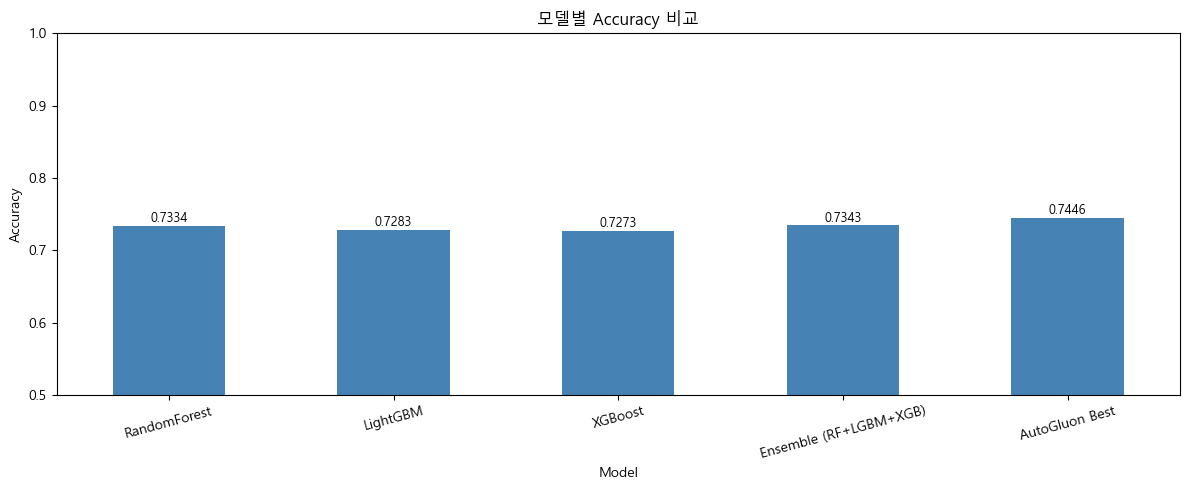

저장 완료: ../outputs/figures/model_comparison.png


In [16]:
fig, ax = plt.subplots(figsize=(12, 5))
eval_df['Accuracy'].plot(kind='bar', ax=ax, rot=15, color='steelblue')
ax.set_title('모델별 Accuracy 비교')
ax.set_ylabel('Accuracy')
ax.set_ylim(0.5, 1.0)
for i, v in enumerate(eval_df['Accuracy']):
    if not np.isnan(v):
        ax.text(i, v + 0.005, f'{v:.4f}', ha='center', fontsize=9)
fig.tight_layout()
fig.savefig(f'{FIGURE_DIR}/model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'저장 완료: {FIGURE_DIR}/model_comparison.png')


## 4.3 Confusion Matrix (전체 모델)

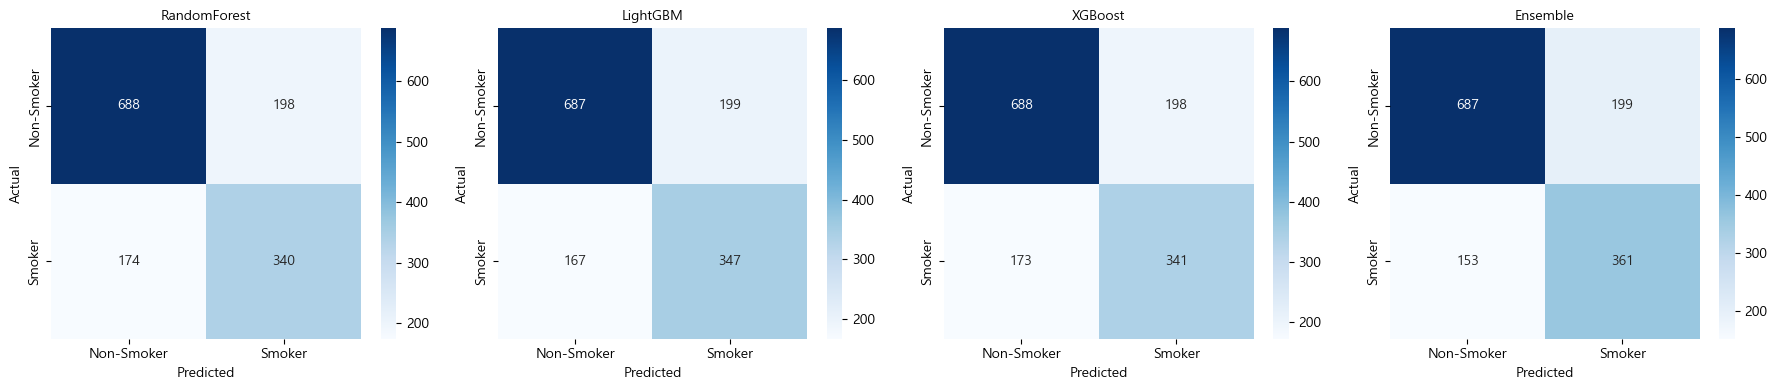

저장 완료: ../outputs/figures/confusion_matrix.png


In [17]:
# 마지막 fold 기준으로 각 모델 confusion matrix 시각화
y_true_last = fold_true[-1]

cm_models = {}
for name, model in sklearn_models.items():
    pred = (fold_probas[name][-1] >= 0.5).astype(int)
    cm_models[name] = confusion_matrix(y_true_last, pred)

# Ensemble
ens_pred_last = (ens_fold_probas[-1] >= 0.5).astype(int)
cm_models['Ensemble'] = confusion_matrix(y_true_last, ens_pred_last)

fig, axes = plt.subplots(1, 4, figsize=(18, 4))
for ax, (name, cm) in zip(axes, cm_models.items()):
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Non-Smoker', 'Smoker'],
                yticklabels=['Non-Smoker', 'Smoker'], ax=ax)
    ax.set_title(name, fontsize=10)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
fig.tight_layout()
fig.savefig(f'{FIGURE_DIR}/confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'저장 완료: {FIGURE_DIR}/confusion_matrix.png')


## 4.4 ROC Curve (전체 모델)

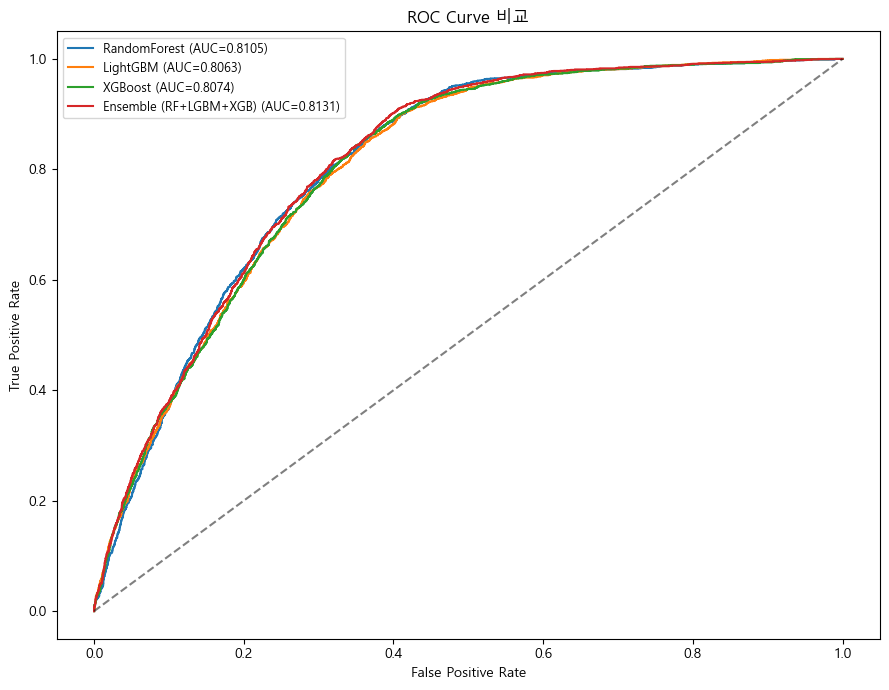

저장 완료: ../outputs/figures/roc_curve.png


In [20]:
# 전체 fold 확률을 이어붙여 ROC 계산
y_true_all = np.concatenate(fold_true)

roc_data = {}
for name in sklearn_models:
    proba_all = np.concatenate(fold_probas[name])
    fpr, tpr, _ = roc_curve(y_true_all, proba_all)
    roc_data[name] = (fpr, tpr, auc(fpr, tpr))

ens_proba_all = np.concatenate(ens_fold_probas)
fpr, tpr, _ = roc_curve(y_true_all, ens_proba_all)
roc_data['Ensemble (RF+LGBM+XGB)'] = (fpr, tpr, auc(fpr, tpr))

fig, ax = plt.subplots(figsize=(9, 7))
for name, (fpr, tpr, roc_auc) in roc_data.items():
    ax.plot(fpr, tpr, label=f'{name} (AUC={roc_auc:.4f})')
ax.plot([0, 1], [0, 1], 'k--', alpha=0.5)
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve 비교')
ax.legend(fontsize=9)
fig.tight_layout()
fig.savefig(f'{FIGURE_DIR}/roc_curve.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'저장 완료: {FIGURE_DIR}/roc_curve.png')


## 4.5 Feature Importance (AutoGluon Best Model)

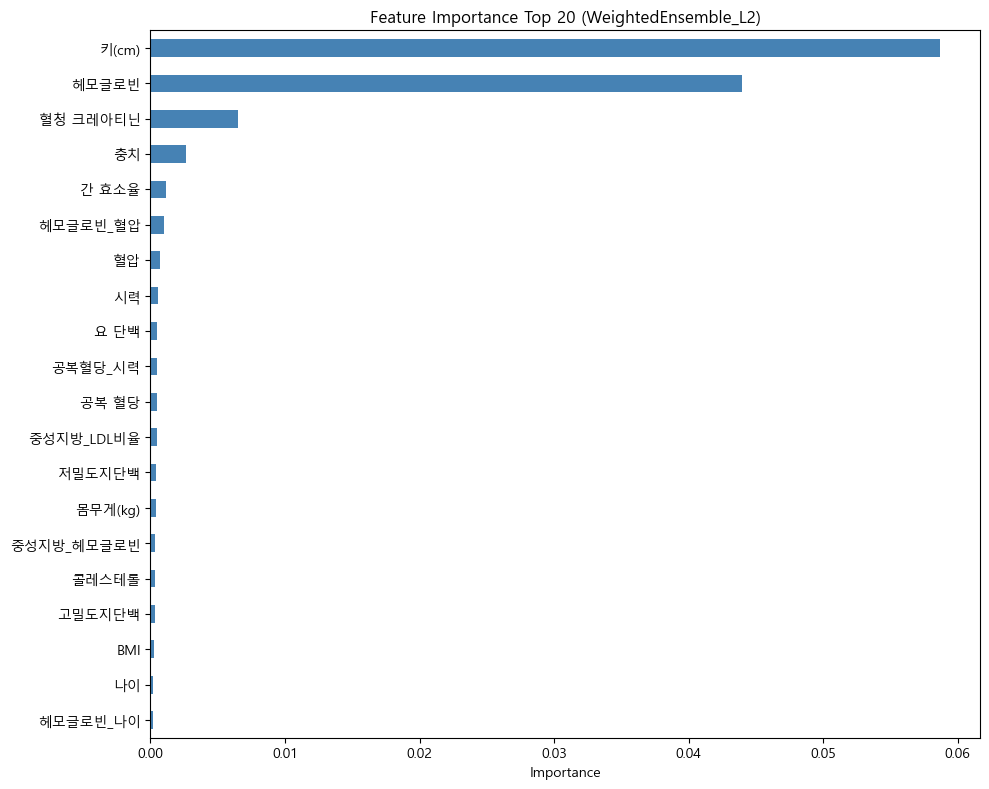

저장 완료: ../outputs/figures/feature_importance.png


In [21]:
feat_imp = predictor.feature_importance(train_data)
top20 = feat_imp.head(20)

fig, ax = plt.subplots(figsize=(10, 8))
top20['importance'][::-1].plot(kind='barh', color='steelblue', ax=ax)
ax.set_yticklabels(top20.index[::-1])
ax.set_title(f'Feature Importance Top 20 ({ag_best_name})')
ax.set_xlabel('Importance')
fig.tight_layout()
fig.savefig(f'{FIGURE_DIR}/feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'저장 완료: {FIGURE_DIR}/feature_importance.png')

## 4.6 결과 요약

In [22]:
best_row = eval_df['F1-score'].idxmax()

print('=' * 55)
print('📊 최종 결과 요약')
print('=' * 55)
print(eval_df.round(4).to_string())
print('=' * 55)
print(f'\n🏆 Best Model (F1 기준): {best_row}')
print(f'   Accuracy:  {eval_df.loc[best_row, "Accuracy"]:.4f}')
print(f'   Precision: {eval_df.loc[best_row, "Precision"]:.4f}')
print(f'   Recall:    {eval_df.loc[best_row, "Recall"]:.4f}')
print(f'   F1-score:  {eval_df.loc[best_row, "F1-score"]:.4f}')
print(f'\n🤖 AutoGluon Best Accuracy (OOF): {eval_df.loc["AutoGluon Best", "Accuracy"]:.4f}')
print('\n저장된 시각화 파일:')
for f in os.listdir(FIGURE_DIR):
    if f.endswith('.png'):
        print(f'  📈 {FIGURE_DIR}/{f}')


📊 최종 결과 요약
                        Accuracy  Precision  Recall  F1-score
Model                                                        
RandomForest              0.7334     0.6384  0.6328    0.6353
LightGBM                  0.7283     0.6305  0.6282    0.6291
XGBoost                   0.7273     0.6291  0.6266    0.6277
Ensemble (RF+LGBM+XGB)    0.7343     0.6379  0.6391    0.6382
AutoGluon Best            0.7446        NaN     NaN       NaN

🏆 Best Model (F1 기준): Ensemble (RF+LGBM+XGB)
   Accuracy:  0.7343
   Precision: 0.6379
   Recall:    0.6391
   F1-score:  0.6382

🤖 AutoGluon Best Accuracy (OOF): 0.7446

저장된 시각화 파일:
  📈 ../outputs/figures/confusion_matrix.png
  📈 ../outputs/figures/feature_importance.png
  📈 ../outputs/figures/model_comparison.png
  📈 ../outputs/figures/roc_curve.png
